# Baseline 5 (Proposed): MS-ProtoNet with ResNet50 (MS-ProtoNet-50)

This notebook implements the **proposed Multi-Scale Prototypical Network** using **ResNet50** as the backbone.

### Key Contributions
- Multi-scale feature extraction from **layer2, layer3, layer4** of ResNet50
- Projection of heterogeneous features to a common embedding space
- Prototypical Network for few-shot classification
- **Feature caching** to reduce redundant computation during episodic training

Few-shot settings evaluated:
- 1-shot
- 5-shot
- 10-shot

## 1. Imports

In [10]:
import os, random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## 2. Image Transform

In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 3. ResNet50 Multi-Scale Feature Extractor

We explicitly extract features from:
- **layer2** → low/mid-level (512 channels)
- **layer3** → mid/high-level (1024 channels)
- **layer4** → high-level semantic features (2048 channels)

All features are projected to a **128-D space** before fusion.

In [12]:
class ResNet50MultiScale(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights=ResNet50_Weights.DEFAULT)

        # Backbone blocks
        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool

        self.layer1 = base.layer1
        self.layer2 = base.layer2  # 512 ch
        self.layer3 = base.layer3  # 1024 ch
        self.layer4 = base.layer4  # 2048 ch

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Projection layers
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(1024, 128)
        self.fc4 = nn.Linear(2048, 128)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual blocks
        x = self.layer1(x)
        f2 = self.layer2(x)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)

        # Pooling
        v2 = self.gap(f2).view(f2.size(0), -1)
        v3 = self.gap(f3).view(f3.size(0), -1)
        v4 = self.gap(f4).view(f4.size(0), -1)

        # Projection
        z2 = self.fc2(v2)
        z3 = self.fc3(v3)
        z4 = self.fc4(v4)

        # Multi-scale fusion (concatenation)
        embedding = torch.cat([z2, z3, z4], dim=1)  # 384-D

        return embedding

## 4. Feature Cache

In [13]:
class FeatureCache:
    def __init__(self):
        self.cache = {}

    def get(self, key):
        return self.cache.get(key, None)

    def set(self, key, value):
        self.cache[key] = value

## 5. Few-Shot Dataset with Cached Features

Each image is passed through the ResNet50 backbone **once**, and the resulting multi-scale embedding is reused across episodes.

In [14]:
class FewShotDataset:
    def __init__(self, root, transform):
        self.root = root
        self.transform = transform

        self.classes = sorted(os.listdir(root))
        self.images = {
            c: [os.path.join(root, c, i) for i in os.listdir(os.path.join(root, c))]
            for c in self.classes
        }
    def sample_episode(self, n_way, k_shot, q_query):
        s_imgs, q_imgs, s_y, q_y = [], [], [], []
        classes = random.sample(self.classes, n_way)

        for label, cls in enumerate(classes):
            images = self.images[cls]

            # 🔒 Handle insufficient images by reuse
            if len(images) < (k_shot + q_query):
                # print(
                #     f"⚠️ Not enough images in class '{cls}'. "
                #     f"Required={k_shot + q_query}, Available={len(images)}. Reusing images."
                # )
                images = (
                    images * ((k_shot + q_query) // len(images) + 1)
                )[: k_shot + q_query]

            sampled_images = random.sample(images, k_shot + q_query)

            # Support set
            for img_path in sampled_images[:k_shot]:
                img = Image.open(img_path).convert("RGB")
                s_imgs.append(self.transform(img))
                s_y.append(label)

            # Query set
            for img_path in sampled_images[k_shot:]:
                img = Image.open(img_path).convert("RGB")
                q_imgs.append(self.transform(img))
                q_y.append(label)

        return (
            torch.stack(s_imgs),
            torch.tensor(s_y),
            torch.stack(q_imgs),
            torch.tensor(q_y),
        )



## 6. Prototypical Network Head

In [15]:
class ProtoNetHead(nn.Module):
    def forward(self, support_emb, support_y, query_emb):
        prototypes = []
        for c in torch.unique(support_y):
            prototypes.append(support_emb[support_y == c].mean(dim=0))
        prototypes = torch.stack(prototypes)

        distances = torch.cdist(query_emb, prototypes)
        return -distances

## 7. Training & Evaluation

In [16]:
def train_and_evaluate(k_shot, episodes_train=100, episodes_eval=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    encoder = ResNet50MultiScale().to(device)
    head = ProtoNetHead().to(device)

    # IMPORTANT: optimize BOTH encoder and head
    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(head.parameters()),
        lr=1e-4
    )

    # Dataset returns IMAGES (not embeddings)
    train_data = FewShotDataset("clean_dataset/train", transform)
    val_data   = FewShotDataset("clean_dataset/val", transform)

    # =========================
    # TRAINING
    # =========================
    encoder.train()
    head.train()

    for ep in range(episodes_train):
        # ---- sample episode (IMAGES) ----
        print(f"Training episode {ep + 1}/100...")
        s_x, s_y, q_x, q_y = train_data.sample_episode(
            n_way=4, k_shot=k_shot, q_query=10
        )

        s_x, s_y = s_x.to(device), s_y.to(device)
        q_x, q_y = q_x.to(device), q_y.to(device)

        # ---- forward pass THROUGH encoder (CRITICAL) ----
        s_emb = encoder(s_x)
        q_emb = encoder(q_x)

        scores = head(s_emb, s_y, q_emb)
        loss = F.cross_entropy(scores, q_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # =========================
    # EVALUATION
    # =========================
    encoder.eval()
    head.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for eval_episode in range(episodes_eval):
            print(f"Evaluating episode {eval_episode + 1}/50...")
            s_x, s_y, q_x, q_y = val_data.sample_episode(
                n_way=4, k_shot=k_shot, q_query=10
            )

            s_x, s_y = s_x.to(device), s_y.to(device)
            q_x, q_y = q_x.to(device), q_y.to(device)

            s_emb = encoder(s_x)
            q_emb = encoder(q_x)

            preds = head(s_emb, s_y, q_emb).argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(q_y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, cm


## 📊 Enhanced Evaluation with Comprehensive Metrics
**BASELINE 5 — MS-ProtoNet-50 (Multi-Scale ResNet50 + ProtoNetHead)**

Evaluates across 1-shot, 5-shot, and 10-shot settings and reports:
- Accuracy, Precision, Recall, F1-score (macro)
- Confusion Matrix per shot setting
- Stability (accuracy std-dev across episodes)

In [17]:
def train_and_evaluate_with_metrics(n_support_list, n_way, n_query, n_train_episodes, n_eval_episodes, learning_rate):
    # ── Device ──────────────────────────────────────────────────────
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print(f"Using device: {device}")
    torch.set_num_threads(os.cpu_count())

    # ── Transform ───────────────────────────────────────────────────
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    # ── Datasets ────────────────────────────────────────────────────
    train_dataset = FewShotDataset("clean_dataset/train", transform)
    test_dataset  = FewShotDataset("clean_dataset/test",  transform)

    results = []

    for n_support in n_support_list:
        print(f"\n{'='*60}")
        print(f"  Training {n_support}-shot ({n_train_episodes} episodes) …")
        print(f"{'='*60}")

        # ── Fresh encoder + head per shot setting ────────────────────
        encoder = ResNet50MultiScale().to(device)
        head    = ProtoNetHead().to(device)
        optimizer = torch.optim.Adam(
            list(encoder.parameters()) + list(head.parameters()),
            lr=learning_rate
        )

        # ── Training ────────────────────────────────────────────────
        encoder.train(); head.train()
        for ep in range(1, n_train_episodes + 1):
            sx, sy, qx, qy = train_dataset.sample_episode(
                n_way=n_way, k_shot=n_support, q_query=n_query)
            sx, sy = sx.to(device), sy.to(device)
            qx, qy = qx.to(device), qy.to(device)

            s_emb = encoder(sx)
            q_emb = encoder(qx)
            scores = head(s_emb, sy, q_emb)
            loss = F.cross_entropy(scores, qy)

            optimizer.zero_grad(); loss.backward(); optimizer.step()

            if ep % 20 == 0:
                print(f"  Episode {ep:>3}/{n_train_episodes}  loss={loss.item():.4f}")

        # ── Evaluation ──────────────────────────────────────────────
        encoder.eval(); head.eval()
        all_preds, all_labels, ep_accs = [], [], []

        with torch.no_grad():
            for ep in range(1, n_eval_episodes + 1):
                sx, sy, qx, qy = test_dataset.sample_episode(
                    n_way=n_way, k_shot=n_support, q_query=n_query)
                sx, sy = sx.to(device), sy.to(device)
                qx, qy = qx.to(device), qy.to(device)

                s_emb = encoder(sx)
                q_emb = encoder(qx)
                scores = head(s_emb, sy, q_emb)
                preds  = scores.argmax(dim=1)

                all_preds .extend(preds.cpu().numpy())
                all_labels.extend(qy.cpu().numpy())
                ep_accs.append(accuracy_score(qy.cpu().numpy(), preds.cpu().numpy()))

        acc  = accuracy_score (all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
        rec  = recall_score   (all_labels, all_preds, average="macro", zero_division=0)
        f1   = f1_score       (all_labels, all_preds, average="macro", zero_division=0)
        cm   = confusion_matrix(all_labels, all_preds)
        stab = np.std(ep_accs)

        results.append({
            "Shot":      f"{n_support}-shot",
            "Accuracy":  acc,
            "Precision": prec,
            "Recall":    rec,
            "F1-Score":  f1,
            "Stability": stab,
            "CM":        cm,
            "EpAccs":    ep_accs,
        })
        print(f"\n  [{n_support}-shot] Acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}  Stab±{stab:.4f}")

    return results

### ▶️ Run Comprehensive Evaluation

In [18]:
results = train_and_evaluate_with_metrics(
    n_support_list   = [1, 5, 10],
    n_way            = 4,
    n_query          = 15,
    n_train_episodes = 2000,
    n_eval_episodes  = 1000,
    learning_rate    = 0.001
)

Using device: mps

  Training 1-shot (2000 episodes) …
  Episode  20/2000  loss=0.0363
  Episode  40/2000  loss=0.0432
  Episode  60/2000  loss=0.0064
  Episode  80/2000  loss=0.0000
  Episode 100/2000  loss=0.0001
  Episode 120/2000  loss=0.0000
  Episode 140/2000  loss=0.0000
  Episode 160/2000  loss=0.0029
  Episode 180/2000  loss=0.0002
  Episode 200/2000  loss=0.0001
  Episode 220/2000  loss=0.0005
  Episode 240/2000  loss=0.0002
  Episode 260/2000  loss=0.0000
  Episode 280/2000  loss=0.0001
  Episode 300/2000  loss=0.0001
  Episode 320/2000  loss=0.0003
  Episode 340/2000  loss=0.0305
  Episode 360/2000  loss=0.0694
  Episode 380/2000  loss=0.0615
  Episode 400/2000  loss=0.1296
  Episode 420/2000  loss=0.0413
  Episode 440/2000  loss=0.0077
  Episode 460/2000  loss=0.1652
  Episode 480/2000  loss=0.0001
  Episode 500/2000  loss=0.0041
  Episode 520/2000  loss=0.0000
  Episode 540/2000  loss=0.0001
  Episode 560/2000  loss=0.0000
  Episode 580/2000  loss=0.0000
  Episode 600/200

### 📈 Results Summary Table

In [19]:
df = pd.DataFrame([
    {
        "Shot":       r["Shot"],
        "Accuracy":   f"{r['Accuracy']:.4f}",
        "Precision":  f"{r['Precision']:.4f}",
        "Recall":     f"{r['Recall']:.4f}",
        "F1-Score":   f"{r['F1-Score']:.4f}",
        "Stability (σ)": f"{r['Stability']:.4f}",
    }
    for r in results
])
df.set_index("Shot", inplace=True)
print("\n📊 Baseline 5 — MS-ProtoNet-50 Performance\n")
print(df.to_string())


📊 Baseline 5 — MS-ProtoNet-50 Performance

        Accuracy Precision  Recall F1-Score Stability (σ)
Shot                                                     
1-shot    0.8317    0.8317  0.8317   0.8317        0.0782
5-shot    0.8914    0.8915  0.8914   0.8914        0.0270
10-shot   0.9145    0.9145  0.9145   0.9145        0.0310


### 🎯 Confusion Matrices (1-shot / 5-shot / 10-shot)

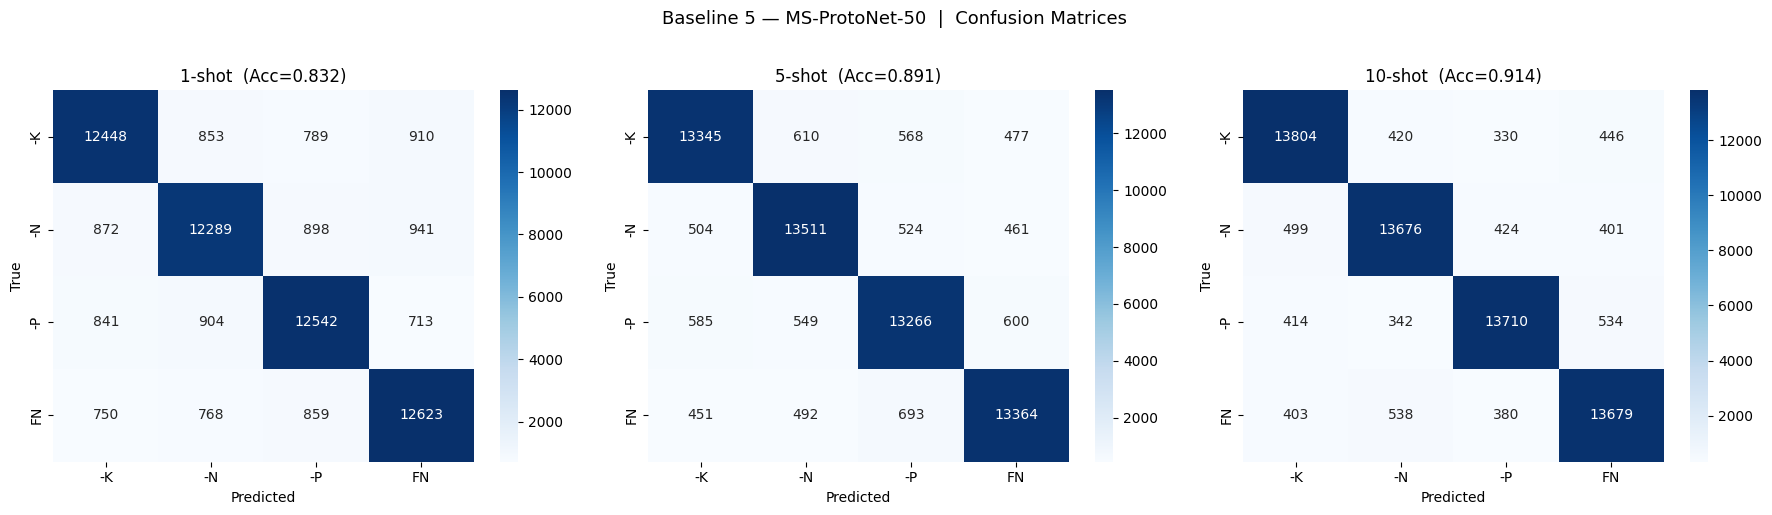

In [20]:
class_names = ["-K", "-N", "-P", "FN"]
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    sns.heatmap(
        r["CM"], annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set_title(f"{r['Shot']}  (Acc={r['Accuracy']:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Baseline 5 — MS-ProtoNet-50  |  Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 📉 Stability Analysis Across Episodes

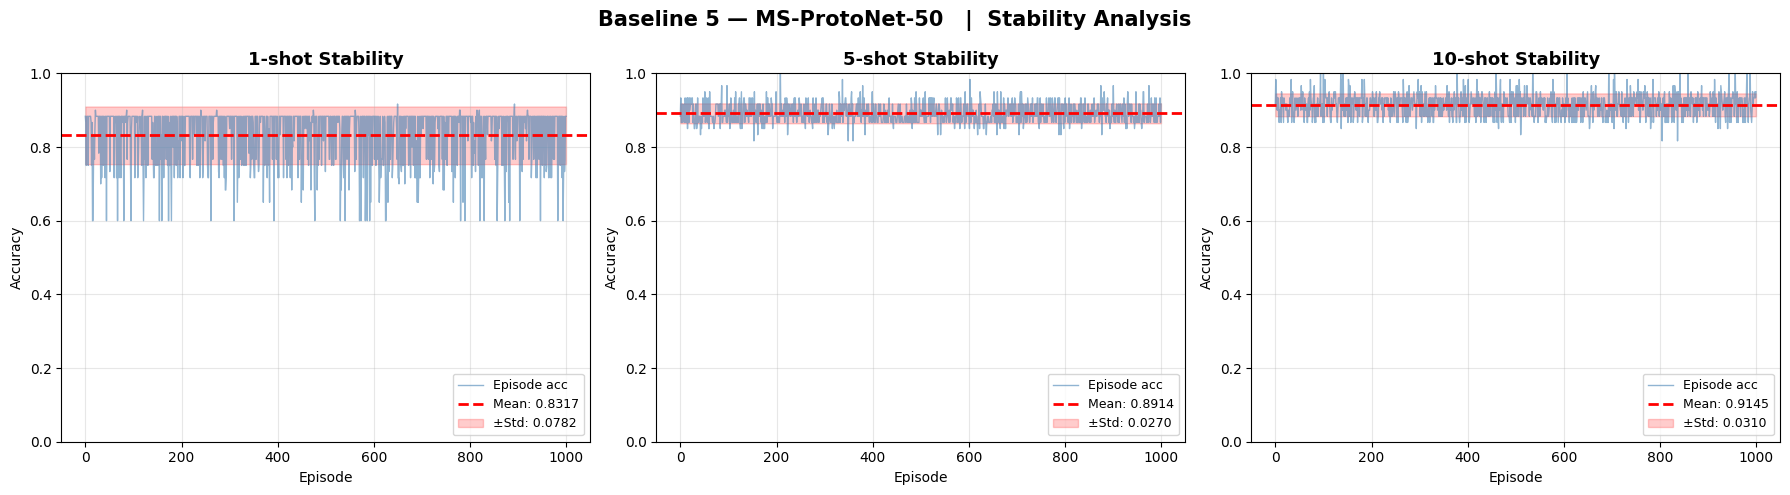

In [22]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    ep_accs = r["EpAccs"]
    mean_acc = r["Accuracy"]
    std_acc  = r["Stability"]

    ax.plot(ep_accs, alpha=0.6, linewidth=1, color='steelblue', label='Episode acc')
    ax.axhline(mean_acc, color='red', linestyle='--', linewidth=2,
               label=f"Mean: {mean_acc:.4f}")
    ax.fill_between(range(len(ep_accs)),
                    mean_acc - std_acc,
                    mean_acc + std_acc,
                    alpha=0.2, color='red', label=f"±Std: {std_acc:.4f}")
    ax.set_title(f"{r['Shot']} Stability", fontsize=13, fontweight='bold')
    ax.set_xlabel("Episode")
    ax.set_ylabel("Accuracy")
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

plt.suptitle("Baseline 5 — MS-ProtoNet-50   |  Stability Analysis", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
